# M8 - Graph Node Embedding and Network Localization:
## A Least Squares and Dirichlet Energy Approach

COE745 — Linear Algebra, Optimization and Data-Driven Control

| Name | Academic Position |
|---|---|
| Bismark Brandi Sigolo | M.Sc. Student in Robotics Engineering |
| Jonas Tobias Ulbrich | Ph.D. Student in Robotics Engineering |
| Rickson Gomes Monteiro | M.Sc. Student in Robotics Engineering |

## Introduction

Graph-based localization problems arise in several engineering and scientific applications, including sensor network positioning, facility placement, robotics, and data visualization. In such problems, the objective is to determine the coordinates of a set of points while preserving neighborhood relationships encoded by a graph.

In this project, each node of an undirected graph represents an object located in the plane, and each edge indicates that the corresponding objects should remain close to one another. Some node locations are fixed and serve as anchors, while the remaining node coordinates must be determined.

The localization task is formulated as an optimization problem in which the sum of squared Euclidean distances between connected nodes is minimized. This objective can be interpreted as a graph smoothness measure and is closely related to the Dirichlet energy associated with the graph. By exploiting this connection, the localization problem can be rewritten as a least-squares problem, allowing the optimal coordinates to be computed efficiently using linear algebra techniques.

The goals of this project are to establish the relationship between the localization objective and the Dirichlet energy, formulate the problem in the standard least-squares framework, and compute the optimal node positions for a given graph instance with prescribed anchor nodes.


## Theoretical Framework and Analytical Proof

The graph localization problem seeks the positions of the first \(N-K\) nodes such that the total squared Euclidean distance between connected nodes is minimized. Let

$$
E = \{(i_1,j_1),\ldots,(i_L,j_L)\}
$$

denote the set of graph edges. The objective function is

$$
\sum_{k=1}^{L}\|p_{i_k}-p_{j_k}\|_2^2.
$$

To relate this expression to the Dirichlet energy, define the vectors containing the horizontal and vertical coordinates of all nodes:

$$
u=((p_1)_1,\ldots,(p_N)_1),
\qquad
v=((p_1)_2,\ldots,(p_N)_2).
$$

Since each point $(p_i\in\mathbb{R}^2)$ is represented by its two coordinates, the squared Euclidean distance associated with an edge $(i_k,j_k)$ can be decomposed as

$$
\|p_{i_k}-p_{j_k}\|_2^2
=
\big((p_{i_k})_1-(p_{j_k})_1\big)^2
+
\big((p_{i_k})_2-(p_{j_k})_2\big)^2.
$$

Using the definitions of \(u\) and \(v\), this becomes

$$
\|p_{i_k}-p_{j_k}\|_2^2
=
(u_{i_k}-u_{j_k})^2
+
(v_{i_k}-v_{j_k})^2.
$$

Summing over all edges yields

$$
\sum_{k=1}^{L}\|p_{i_k}-p_{j_k}\|_2^2
=
\sum_{k=1}^{L}(u_{i_k}-u_{j_k})^2
+
\sum_{k=1}^{L}(v_{i_k}-v_{j_k})^2.
$$

Recall that the Dirichlet energy of a function \(f\) defined on the graph vertices is

$$
D(f)=\sum_{(i,j)\in E}(f_i-f_j)^2.
$$

Therefore,

$$
D(u)=\sum_{k=1}^{L}(u_{i_k}-u_{j_k})^2,
\qquad
D(v)=\sum_{k=1}^{L}(v_{i_k}-v_{j_k})^2.
$$

Substituting these expressions into the objective function gives

$$
\sum_{k=1}^{L}\|p_{i_k}-p_{j_k}\|_2^2
=
D(u)+D(v).
$$

Thus, minimizing the total squared distance between connected nodes is equivalent to minimizing the sum of the Dirichlet energies associated with the horizontal and vertical coordinates of the graph.

## Formulation as a Standard Least Squares Problem

To map this problem to the canonical least squares form $\min_x \|Ax - b\|_2^2$, we can utilize the graph incidence matrix $C \in \mathbb{R}^{L \times N}$. For each edge $e = (i,j)$ with $i < j$, row $e$ of matrix $C$ has a $1$ at column $i$, a $-1$ at column $j$, and $0$ elsewhere.

Multiplying $C$ by a coordinate vector yields the differences along the edges, meaning that $D(u) = \|Cu\|_2^2$ and $D(v) = \|Cv\|_2^2$. We can partition the columns of $C$ into two blocks: $C_f \in \mathbb{R}^{L \times (N-K)}$ corresponding to the first $N-K$ free nodes, and $C_k \in \mathbb{R}^{L \times K}$ corresponding to the last $K$ fixed nodes:  
$$
C = \begin{bmatrix} C_f & C_k \end{bmatrix}
$$

Using this block structure, the coordinate vectors can be written as $u = \begin{bmatrix} u_{\text{free}} \\ u_{\text{fixed}} \end{bmatrix}$ and $v = \begin{bmatrix} v_{\text{free}} \\ v_{\text{fixed}} \end{bmatrix}$. Expanding the matrix-vector products gives:
$$
Cu = C_f u_{\text{free}} + C_k u_{\text{fixed}} \quad \Longrightarrow \quad D(u) = \|C_f u_{\text{free}} - (-C_k u_{\text{fixed}})\|_2^2
$$
$$
Cv = C_f v_{\text{free}} + C_k v_{\text{fixed}} \quad \Longrightarrow \quad D(v) = \|C_f v_{\text{free}} - (-C_k v_{\text{fixed}})\|_2^2
$$

Since the optimization variable is the stacked vector $x = \begin{bmatrix} u_{\text{free}} \\ v_{\text{free}} \end{bmatrix} \in \mathbb{R}^{2(N-K)}$, we combine both independent components into a single overdetermined system:
$$
\min_x \left\| \begin{bmatrix} C_f & 0 \\ 0 & C_f \end{bmatrix} \begin{bmatrix} u_{\text{free}} \\ v_{\text{free}} \end{bmatrix} - \begin{bmatrix} -C_k u_{\text{fixed}} \\ -C_k v_{\text{fixed}} \end{bmatrix} \right\|_2^2
$$

By setting the system matrix $A$ and the target vector $b$ to:
$$
A = \begin{bmatrix} C_f & 0 \\ 0 & C_f \end{bmatrix}, \qquad
b = \begin{bmatrix} -C_k u_{\text{fixed}} \\ -C_k v_{\text{fixed}} \end{bmatrix}
$$
the problem is exactly cast in the standard linear least squares framework:
$$
\min_x \|Ax - b\|_2^2
$$

This formulation allows the optimal node locations to be computed efficiently using standard linear least squares techniques like implemented below.

Coordenadas Ótimas:
Nó p1 = (0.3553, 0.3480)
Nó p2 = (0.5311, 0.7985)
Nó p3 = (0.5128, 0.5641)
Nó p4 = (0.5531, 0.4799)
Nó p5 = (0.6117, 0.6300)
Nó p6 = (0.7912, 0.5275)


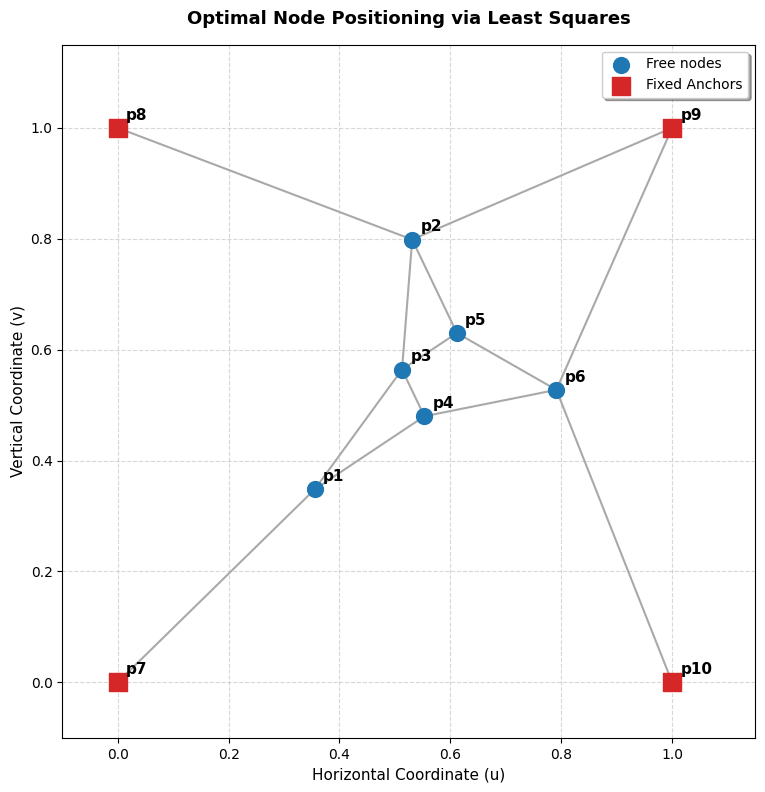

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Dados do enunciado
N = 10
K = 4
L = 13
free_nodes = N - K  # 6 nós livres

# Lista de arestas 
edges = [
    (1, 3), (1, 4), (1, 7),
    (2, 3), (2, 5), (2, 8), (2, 9),
    (3, 4), (3, 5),
    (4, 6),
    (5, 6),
    (6, 9), (6, 10)
]

#Posições fixas: p7=(0,0), p8=(0,1), p9=(1,1), p10=(1,0)
fixed_pos = {
    7: (0.0, 0.0),
    8: (0.0, 1.0),
    9: (1.0, 1.0),
    10: (1.0, 0.0)
}

# 2. Criando as matrizes do sistema de Mínimos Quadrados (A*x = b)
# 13 linhas para u e 13 linhas para v -> total 26 linhas
# 6 colunas para u e 6 colunas para v -> total 12 colunas 
A = np.zeros((2 * L, 2 * free_nodes))
b = np.zeros(2 * L)

for idx, (i, j) in enumerate(edges):
    # --- Componente Horizontal U (Linhas 0 a 12) ---
    # Equação estrutural: u_i - u_j = 0
    if i <= free_nodes:
        A[idx, i - 1] = 1.0
    else:
        # Se 'i' for fixo, mudamos o sinal ao passar para o vetor b (-u_i)
        b[idx] -= fixed_pos[i][0]
        
    if j <= free_nodes:
        A[idx, j - 1] = -1.0
    else:
        # Se 'j' for fixo, mudamos o sinal ao passar para o vetor b (-(-u_j) = +u_j)
        b[idx] += fixed_pos[j][0]

    # --- Componente Vertical V (Linhas 13 a 25) ---
    # Equação estrutural: v_i - v_j = 0
    v_idx = idx + L
    if i <= free_nodes:
        A[v_idx, (i - 1) + free_nodes] = 1.0
    else:
        b[v_idx] -= fixed_pos[i][1]
        
    if j <= free_nodes:
        A[v_idx, (j - 1) + free_nodes] = -1.0
    else:
        b[v_idx] += fixed_pos[j][1]

# 3. Resolução por Mínimos Quadrados
x_opt, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

u_free = x_opt[:6]
v_free = x_opt[6:]

u_fixed = np.array([fixed_pos[idx][0] for idx in range(7, 11)])
v_fixed = np.array([fixed_pos[idx][1] for idx in range(7, 11)])
u_all = np.concatenate([u_free, u_fixed])
v_all = np.concatenate([v_free, v_fixed])

print("Coordenadas Ótimas:")
for i in range(free_nodes):
    print(f"Nó p{i+1} = ({u_free[i]:.4f}, {v_free[i]:.4f})")

plt.figure(figsize=(9, 9))

for n1, n2 in edges:
    plt.plot([u_all[n1-1], u_all[n2-1]], [v_all[n1-1], v_all[n2-1]], 
             color='darkgray', linestyle='-', linewidth=1.5, zorder=1)

plt.scatter(u_all[:free_nodes], v_all[:free_nodes], 
            color='#1f77b4', s=130, marker='o', label='Free nodes', zorder=2)

plt.scatter(u_all[free_nodes:], v_all[free_nodes:], 
            color='#d62728', s=150, marker='s', label='Fixed Anchors', zorder=2)

for idx in range(N):
    plt.text(u_all[idx] + 0.015, v_all[idx] + 0.015, f'p{idx+1}', fontsize=11, fontweight='bold')

plt.title('Optimal Node Positioning via Least Squares', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Horizontal Coordinate (u)', fontsize=11)
plt.ylabel('Vertical Coordinate (v)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.xlim(-0.1, 1.15)
plt.ylim(-0.1, 1.15)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

**Conclusion and Discussion**

The computed solution exhibits a smooth spatial distribution of the free nodes between the four fixed anchor points. This behavior is expected from the minimization of the Dirichlet energy, since each free node tends to occupy a position that balances the influence of its neighboring nodes.

Nodes connected to multiple anchors are pulled toward the center of the domain, while nodes connected predominantly to one side of the graph are displaced accordingly. For example, node $p_2$ is strongly influenced by the fixed nodes $p_8$ and $p_9$, resulting in a position closer to the upper portion of the square. Similarly, node $p_6$ is directly connected to $p_9$ and $p_{10}$ and therefore lies near the right boundary.

The least-squares formulation provides an efficient computational approach because the original geometric optimization problem reduces to solving a linear system. Furthermore, each free node is approximately located at the average position of its neighboring nodes.